In [41]:
from matplotlib import pyplot as plt
import numpy as np
import kuibit.simdir as SD
from RVSS_EOS_Slope import RVSS_EOS_Slope as rvss_eos

import re
import h5py as h5
from kuibit.visualize_matplotlib import (
    add_text_to_corner,
    get_figname,
    plot_color,
    plot_contour,
    plot_components_boundaries,
    plot_horizon_on_plane_at_iteration,
    save_from_dir_filename_ext,
    set_axis_limits,
    setup_matplotlib
)
from kuibit import grid_data_utils as gdu
from kuibit import grid_data as gd
import pickle
from scipy.interpolate import interp1d


In [9]:
#Physical Constants
c = 299792458  # Speed of light in m/s
G = 6.67430e-11  # Gravitational constant in m^3/kg/s^2
hc = 197.3 #hbar c Mev fm

#Nuclear Physics Parameters
n0 = 0.16
mn = 939.56

#TOV Solver parameters

epsilon = mn*n0 #TOV solver energy scale

#Conversion Factors
geometrized_to_SI = c**2 / G  # Conversion factor from geometrized units to SI units (kg/m^3)
geometrized_to_SI_Press = c**4 / G
meters_to_msol = geometrized_to_SI/(1.989*10**30)
kg_to_g = 1000  # Conversion factor from kg to g
m3_to_cm3 = 1e6  # Conversion factor from m^3 to cm^3
freq_code_u_to_hz = 203000
time_code_u_to_ms = 1/203
geometrized_to_SI = c**2 / G  # Conversion factor from geometrized units to SI units (kg/m^3)
kg_to_g = 1000  # Conversion factor from kg to g
m3_to_cm3 = 1e6  # Conversion factor from m^3 to cm^3
geometrized_code_to_nb = (((geometrized_to_SI*(1/1476)**2)*kg_to_g/m3_to_cm3)/(1.6582*10**(-24)))*(1/(10**39))
J_m3_toMeV_fm3 = 5.605*10**(-16)
Pa_to_MeV_fm3 = 6.242*10**(-33)

In [10]:
with open('./Interpreters/Alph_A_cs2_nb_interp.pkl','rb') as file:
    Alpha_A_Interp = pickle.load(file)

with open('./Interpreters/Alph_A_nb_eps_interp.pkl','rb') as file:
    Alpha_A_eps_interp = pickle.load(file)
with open('./Interpreters/Alph_A_nb_pres_interp.pkl','rb') as file:
    Alpha_A_pres_interp = pickle.load(file)
with open('./Interpreters/Alph_D_cs2_nb_interp.pkl','rb') as file:
    Alpha_D_Interp = pickle.load(file)

with open('./Interpreters/Alph_B_cs2_nb_interp.pkl','rb') as file:
    Alpha_B_Interp = pickle.load(file)

with open('./Interpreters/Alph_E_cs2_nb_interp.pkl','rb') as file:
    Alpha_E_interp = pickle.load(file)

with open('./Interpreters/Alph_C_cs2_nb_interp.pkl','rb') as file:
    Alpha_C_interp = pickle.load(file)



In [11]:
EOS_V = rvss_eos(1200,mu_max=2700)
EOS_IV = rvss_eos(1300,mu_max=2700)
EOS_III = rvss_eos(1400,mu_max=2700)
EOS_II = rvss_eos(1500,mu_max=2700)
EOS_I = rvss_eos(1700,mu_max=2700)

RVSS_List = {'A': (EOS_V,'red'),
             'E': (EOS_IV,'blue'),
             'B': (EOS_III,'green'),
             'D': (EOS_I,'black'),
             'C': (EOS_II,'purple')}

matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051


/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/RVSS_EOS_Slope.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_pr = press_compose[-1] + quad(lambda mu_p: nb_interp(mu_p),mu_m,mu,limit=200)


Done
alpha = 0.003985692037555738
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002761607731865443
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002112742893851452
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0017107796622185417
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0012392345966394309


In [12]:
EOS_I_eps_interp = interp1d(EOS_I.nb_unified,EOS_I.E_unified)
EOS_I_pres_interp = interp1d(EOS_I.nb_unified,EOS_I.P_unified)

EOS_II_eps_interp = interp1d(EOS_II.nb_unified,EOS_II.E_unified)
EOS_II_pres_interp = interp1d(EOS_II.nb_unified,EOS_II.P_unified)
EOS_II_cs2_interp = interp1d(EOS_II.nb_unified,EOS_II.cs2_unified)

EOS_III_eps_interp = interp1d(EOS_III.nb_unified,EOS_III.E_unified)
EOS_III_pres_interp = interp1d(EOS_III.nb_unified,EOS_III.P_unified)


EOS_IV_eps_interp = interp1d(EOS_IV.nb_unified,EOS_IV.E_unified)
EOS_IV_pres_interp = interp1d(EOS_IV.nb_unified,EOS_IV.P_unified)

EOS_V_eps_interp = interp1d(EOS_V.nb_unified,EOS_V.E_unified)
EOS_V_pres_interp = interp1d(EOS_V.nb_unified,EOS_V.P_unified)
EOS_V_cs2_interp = interp1d(EOS_V.nb_unified,EOS_V.cs2_unified)

In [13]:
def geom_to_nucl_rho(data):
    return data*geometrized_code_to_nb

def geom_to_nucl_pres(data):
    return data*geometrized_to_SI_Press*Pa_to_MeV_fm3*((1/1476)**2)

def geom_to_nucl_eps(data):
    return data*((1/1476)**2)*geometrized_to_SI_Press*Pa_to_MeV_fm3

In [14]:
#-------------------------------Sim Dirs for 1.4M BNS Mergers------------------------------------------------------------------------
rvss_alpha_a_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model A/1p4M_1p4M',
                             pickle_file='/mnt/John_Backup/RVSS Data/Model A/1p4M_1p4M/sim.pickle')
print('Alpha A 1.4M Sim Dir Finished')
rvss_alpha_b_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model B/1p4M_1p4M',
                             pickle_file='/mnt/John_Backup/RVSS Data/Model B/1p4M_1p4M/sim.pickle')
print('Alpha B 1.4M Sim Dir Finished')
rvss_alpha_c_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model C/1p4M_1p4M',
                              pickle_file='/mnt/John_Backup/RVSS Data/Model C/1p4M_1p4M/sim.pickle')
print('Alpha C 1.4M Sim Dir Finished')
rvss_alpha_d_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model_D/1p4M_1p4M',
                              pickle_file='/mnt/John_Backup/Model_D/1p4M_1p4M/sim.pickle')
print('Alpha D 1.4M Sim Dir Finished')
rvss_alpha_e_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model_E/1p4M',
                              pickle_file='/mnt/John_Backup/RVSS Data/Model_E/1p4M/sim.pickle')
print('Alpha E 1.4M Finished')


print("Starting 1.3M Simulations")
#-------------------------------Sim Dirs for 1.3M BNS Mergers-------------------------------------------------------------------------
rvss_alpha_a_1p3_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model A/1p3M_1p3M',
                             pickle_file='/mnt/John_Backup/RVSS Data/Model A/1p3M_1p3M/sim.pickle')
print("Alpha A 1.3 M Finished")
rvss_alpha_b_1p3_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model B/1p3M_1p3M',
                             pickle_file='/mnt/John_Backup/RVSS Data/Model B/1p3M_1p3M/sim.pickle')
print("Alpha B 1.3M Finished")
rvss_alpha_c_1p3_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model C/1p3M_1p3M',
                             pickle_file='/mnt/John_Backup/RVSS Data/Model C/1p3M_1p3M/sim.pickle')
print("Alpha C 1.3M Finished")
rvss_alpha_d_1p3_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model_D/1p3M_1p3M',
                             pickle_file='/mnt/John_Backup/RVSS Data/1p3M_1p3M/sim.pickle')
print('Alpha D 1.3M Finished')
rvss_alpha_e_1p3_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model_E/1p3M',
                                 pickle_file='/mnt/John_Backup/RVSS Data/Model_E/1p3M/sim.pickle')
print('Alpha E 1.3M Finished')

# #------------------------------Sim Dirs for 1.35M BNS Mergers------------------------------------------------------------------------
rvss_alpha_e_1p35_dir = SD.SimDir('/mnt/John_Backup/RVSS Data/Model_E/1p35M',
                                  pickle_file='/mnt/John_Backup/RVSS Data/Model_E/1p35M/sim.pickle')

# print('Alpha E 1.35 M Finished')

Alpha A 1.4M Sim Dir Finished
Alpha B 1.4M Sim Dir Finished
Alpha C 1.4M Sim Dir Finished
Alpha D 1.4M Sim Dir Finished
Alpha E 1.4M Finished
Starting 1.3M Simulations
Alpha A 1.3 M Finished
Alpha B 1.3M Finished
Alpha C 1.3M Finished
Alpha D 1.3M Finished
Alpha E 1.3M Finished


In [15]:
Alph_A_1p4_GF = rvss_alpha_a_dir.gridfunctions['xy']
Alph_B_1p4_GF = rvss_alpha_b_dir.gridfunctions['xy']
Alph_C_1p4_GF = rvss_alpha_c_dir.gridfunctions['xy']
Alph_D_1p4_GF = rvss_alpha_d_dir.gridfunctions['xy']
Alph_E_1p4_GF = rvss_alpha_e_dir.gridfunctions['xy']

Alph_A_1p3_GF = rvss_alpha_a_1p3_dir.gridfunctions['xy']
Alph_B_1p3_GF = rvss_alpha_b_1p3_dir.gridfunctions['xy']
Alph_C_1p3_GF = rvss_alpha_c_1p3_dir.gridfunctions['xy']
Alph_D_1p3_GF = rvss_alpha_d_1p3_dir.gridfunctions['xy']
Alph_E_1p3_GF = rvss_alpha_e_1p3_dir.gridfunctions['xy']

Alph_E_1p35_GF = rvss_alpha_e_1p35_dir.gridfunctions['xy']

In [16]:
Alpha_A_1p3_vel_x = Alph_A_1p3_GF['vel[0]']
Alpha_A_1p3_vel_y = Alph_A_1p3_GF['vel[1]']

Alpha_C_1p3_vel_x = Alph_C_1p3_GF['vel[0]']
Alpha_C_1p3_vel_y = Alph_C_1p3_GF['vel[1]']

In [17]:
Alpha_A_1p3_rho = Alph_A_1p3_GF['rho']
Alpha_C_1p3_rho = Alph_C_1p3_GF['rho']

In [18]:
def get_rho_frame(rho_hgrid,ref_levels=[6,5,4]):
    rho_components = []

    for ref in ref_levels:
        for i in range(len(rho_hgrid[ref])):
            ugdata_i = rho_hgrid[ref][i]
            rho_ugdata = geom_to_nucl_rho(ugdata_i.data)
            rho_components.append(gd.UniformGridData(ugdata_i.grid,rho_ugdata))
    rho_hgrid_out = gd.HierarchicalGridData(rho_components)
    return rho_hgrid_out


In [19]:
def get_vmag_frame(vx_hgrid,vy_hgrid,ref_levels=[6,5,4]):
    vmag_components = []
    for ref in ref_levels:
        for i in range(len(vx_hgrid[ref])):
            ug_vxdata = vx_hgrid[ref][i]
            ug_vydata = vy_hgrid[ref][i]
            ug_vmagdata = np.sqrt(ug_vxdata.data**2 + ug_vydata.data**2)
            vmag_components.append(gd.UniformGridData(ug_vxdata.grid,ug_vmagdata))
    vmag_hgrid_out = gd.HierarchicalGridData(vmag_components)
    return vmag_hgrid_out



In [20]:
Gamma_th = 1.7
def get_cs2_frame(eps_interp,pres_interp,cs2_cold_interp,gf,idx,max_cs2_tab=None,max_cs2_t=None,no_frame=False):
    max_cs2 = -1
    components = []
    rho_gf = gf['rho']
    press_gf = gf['press']

    iter = rho_gf.available_iterations[idx]
    t = rho_gf.available_times[idx]

    rho_t = rho_gf[iter]
    press_t = press_gf[iter]

    for ug_rho,ug_press in zip(rho_t,press_t):

        ug_rho_conv = geom_to_nucl_rho(ug_rho[2])
        ug_pres_conv = geom_to_nucl_pres(ug_press[2])    

        
        cold_pres = pres_interp(ug_rho_conv.data)
        cold_eps = eps_interp(ug_rho_conv.data)
        cold_rho = ug_rho_conv.data
        cold_cs2 = cs2_cold_interp(ug_rho_conv.data)

        cold_h = (cold_pres + cold_eps)/(cold_rho)

        P_th = (ug_pres_conv.data - cold_pres)

        T = P_th/(cold_rho)

        thermal_h = Gamma_th*T/(Gamma_th - 1.0)
        hcs2_cold = cold_h*cold_cs2
        hcs2_therm = Gamma_th*T

        cs2_data = np.sqrt((hcs2_cold + hcs2_therm)/(cold_h + thermal_h))

        if np.max(cs2_data) > max_cs2:
            max_cs2 = np.max(cs2_data)
        components.append(gd.UniformGridData(ug_rho[2].grid,cs2_data))


    if max_cs2_tab is not None:
        max_cs2_tab.append(max_cs2)
        max_cs2_t.append(t)
    
    if not no_frame:
        frame = gd.HierarchicalGridData(components)
        return frame
    

In [21]:
def get_T_frame(pres_interp,gf,idx,no_frame=False):
    components = []
    rho_gf = gf['rho']
    press_gf = gf['press']

    iter = rho_gf.available_iterations[idx]
    t = rho_gf.available_times[idx]

    rho_t = rho_gf[iter]
    press_t = press_gf[iter]

    for ug_rho,ug_press in zip(rho_t,press_t):

        ug_rho_conv = geom_to_nucl_rho(ug_rho[2])
        ug_pres_conv = geom_to_nucl_pres(ug_press[2])    

        
        cold_pres = pres_interp(ug_rho_conv.data)
        cold_rho = ug_rho_conv.data


        P_th = (ug_pres_conv.data - cold_pres)

        T = P_th/(cold_rho)

        components.append(gd.UniformGridData(ug_rho[2].grid,T))


   
    
    if not no_frame:
        frame = gd.HierarchicalGridData(components)
        return frame
    

In [22]:
A_t_mrg_idx = 112
C_t_mrg_idx = 124

A_t_1ms_idx = 122
C_t_1ms_idx = 134

A_t_3ms_idx = 142
C_t_3ms_idx = 154

In [26]:
t_A_mrg = Alpha_A_1p3_rho.available_iterations[A_t_mrg_idx]
t_C_mrg = Alpha_C_1p3_rho.available_iterations[C_t_mrg_idx]
A_1p3_rho_mrg = Alpha_A_1p3_rho[t_A_mrg]
C_1p3_rho_mrg = Alpha_C_1p3_rho[t_C_mrg]
A_1p3_velx_mrg = Alpha_A_1p3_vel_x[t_A_mrg]
A_1p3_vely_mrg = Alpha_A_1p3_vel_y[t_A_mrg]

C_1p3_velx_mrg = Alpha_C_1p3_vel_x[t_C_mrg]
C_1p3_vely_mrg = Alpha_C_1p3_vel_y[t_C_mrg]

t_A_1ms = Alpha_A_1p3_rho.available_iterations[A_t_1ms_idx]
t_C_1ms = Alpha_C_1p3_rho.available_iterations[C_t_1ms_idx]
A_1p3_rho_1ms = Alpha_A_1p3_rho[t_A_1ms]
C_1p3_rho_1ms = Alpha_C_1p3_rho[t_C_1ms]
A_1p3_velx_1ms = Alpha_A_1p3_vel_x[t_A_1ms]
A_1p3_vely_1ms = Alpha_A_1p3_vel_y[t_A_1ms]

C_1p3_velx_1ms = Alpha_C_1p3_vel_x[t_C_1ms]
C_1p3_vely_1ms = Alpha_C_1p3_vel_y[t_C_1ms]


t_A_3ms = Alpha_A_1p3_rho.available_iterations[A_t_3ms_idx]
t_C_3ms = Alpha_C_1p3_rho.available_iterations[C_t_3ms_idx]
A_1p3_rho_3ms = Alpha_A_1p3_rho[t_A_3ms]
C_1p3_rho_3ms = Alpha_C_1p3_rho[t_C_3ms]
A_1p3_velx_3ms = Alpha_A_1p3_vel_x[t_A_3ms]
A_1p3_vely_3ms = Alpha_A_1p3_vel_y[t_A_3ms]

C_1p3_velx_3ms = Alpha_C_1p3_vel_x[t_C_3ms]
C_1p3_vely_3ms = Alpha_C_1p3_vel_y[t_C_3ms]


In [60]:
EOS_V_1p3_mrg_data_cs2 = get_cs2_frame(EOS_V_eps_interp,EOS_V_pres_interp,EOS_V_cs2_interp,Alph_A_1p3_GF,A_t_mrg_idx)
EOS_V_1p3_1ms_data_cs2 = get_cs2_frame(EOS_V_eps_interp,EOS_V_pres_interp,EOS_V_cs2_interp,Alph_A_1p3_GF,A_t_1ms_idx)
EOS_V_1p3_3ms_data_cs2 = get_cs2_frame(EOS_V_eps_interp,EOS_V_pres_interp,EOS_V_cs2_interp,Alph_A_1p3_GF,A_t_3ms_idx)

EOS_II_1p3_mrg_data_cs2 = get_cs2_frame(EOS_II_eps_interp,EOS_II_pres_interp,EOS_II_cs2_interp,Alph_C_1p3_GF,C_t_mrg_idx)
EOS_II_1p3_1ms_data_cs2 = get_cs2_frame(EOS_II_eps_interp,EOS_II_pres_interp,EOS_II_cs2_interp,Alph_C_1p3_GF,C_t_1ms_idx)
EOS_II_1p3_3ms_data_cs2 = get_cs2_frame(EOS_II_eps_interp,EOS_II_pres_interp,EOS_II_cs2_interp,Alph_C_1p3_GF,C_t_3ms_idx)

In [59]:
EOS_V_1p3_mrg_data_T = get_T_frame(EOS_V_pres_interp,Alph_A_1p3_GF,A_t_mrg_idx)
EOS_V_1p3_1ms_data_T = get_T_frame(EOS_V_pres_interp,Alph_A_1p3_GF,A_t_1ms_idx)
EOS_V_1p3_3ms_data_T = get_T_frame(EOS_V_pres_interp,Alph_A_1p3_GF,A_t_3ms_idx)

EOS_II_1p3_mrg_data_T = get_T_frame(EOS_II_pres_interp,Alph_C_1p3_GF,C_t_mrg_idx)
EOS_II_1p3_1ms_data_T = get_T_frame(EOS_II_pres_interp,Alph_C_1p3_GF,C_t_1ms_idx)
EOS_II_1p3_3ms_data_T = get_T_frame(EOS_II_pres_interp,Alph_C_1p3_GF,C_t_3ms_idx)

In [61]:
EOS_V_1p3_mrg_data_rho = get_rho_frame(A_1p3_rho_mrg)
EOS_V_1p3_1ms_data_rho = get_rho_frame(A_1p3_rho_1ms)
EOS_V_1p3_3ms_data_rho = get_rho_frame(A_1p3_rho_3ms)

EOS_II_1p3_mrg_data_rho = get_rho_frame(C_1p3_rho_mrg)
EOS_II_1p3_1ms_data_rho = get_rho_frame(C_1p3_rho_1ms)
EOS_II_1p3_3ms_data_rho = get_rho_frame(C_1p3_rho_3ms)

In [62]:
setup_matplotlib({
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

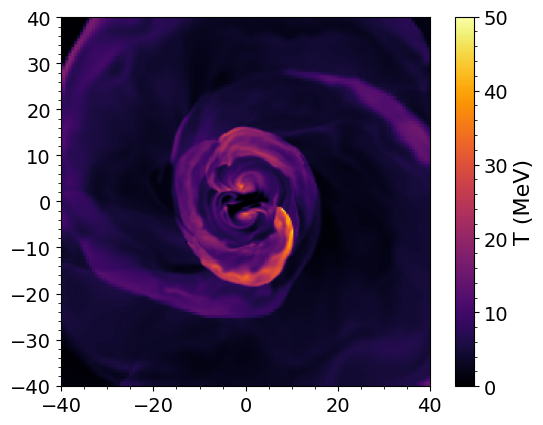

In [66]:
T_fig,T_axes = plt.subplots(1)
plot_color(EOS_II_1p3_mrg_data_T,
            shape=[250,250],
            x0=[-40,-40],
            x1=[40,40],
            vmax=50,
            vmin=0,
            logscale=False,
            colorbar=True,
            axes=T_axes,
            cmap='inferno',
            label='T (MeV)')

[<Axes: >, <Axes: ylabel='T (MeV)'>]


Text(0, 0.5, '$y~(M_\\odot)$')

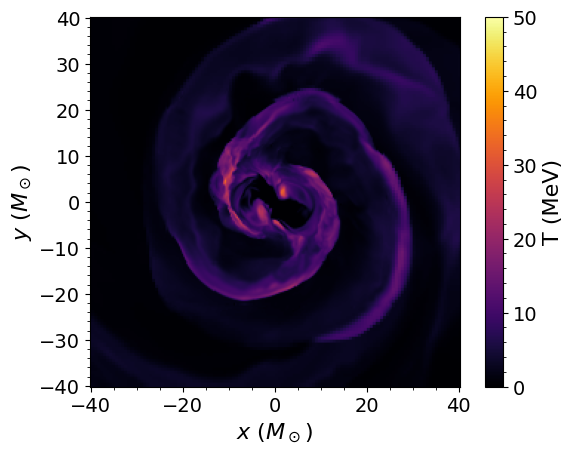

In [67]:
T_fig,T_axes = plt.subplots(1)
im = plot_color(EOS_V_1p3_mrg_data_T,
            shape=[250,250],
            x0=[-40,-40],
            x1=[40,40],
            vmax=50,
            vmin=0,
            logscale=False,
            colorbar=True,
            axes = T_axes,
            figure=T_fig,
            cmap='inferno',
            label="T (MeV)"
            )
print(T_fig.axes)
cbar = plt.colorbar
T_axes.set_xlabel(r"$x~(M_\odot)$")
T_axes.set_ylabel(r"$y~(M_\odot)$")

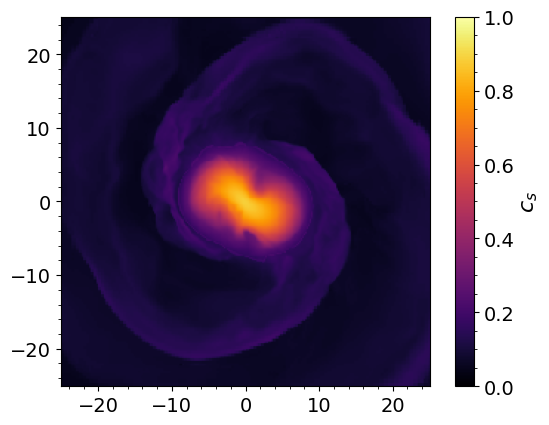

In [54]:
cs2_fig,cs2_axes = plt.subplots(1)
plot_color(EOS_V_1p3_mrg_data_cs2,
            shape=[250,250],
            x0=[-25,-25],
            x1=[25,25],
            vmin=0,
            vmax=1.0,
            logscale=False,
            colorbar=True,
            axes=cs2_axes,
            label="$c_s$")


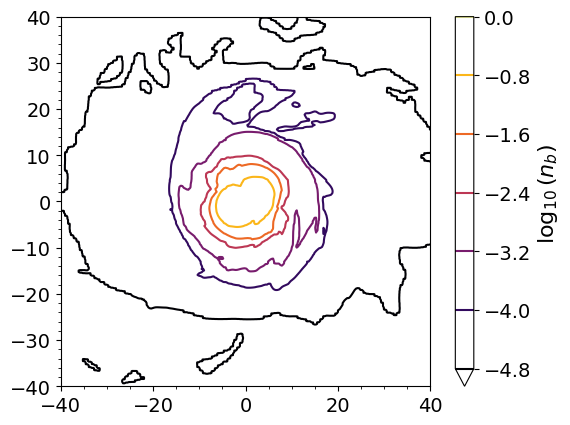

In [79]:
plot_contour(EOS_II_1p3_mrg_data_rho,
            shape=[250,250],
            x0=[-40,-40],
            x1=[40,40],
            vmin=-5,
            vmax=0,
            logscale=True,
            colorbar=True,
            label=r"$\log_{10}\left(n_b\right)$")

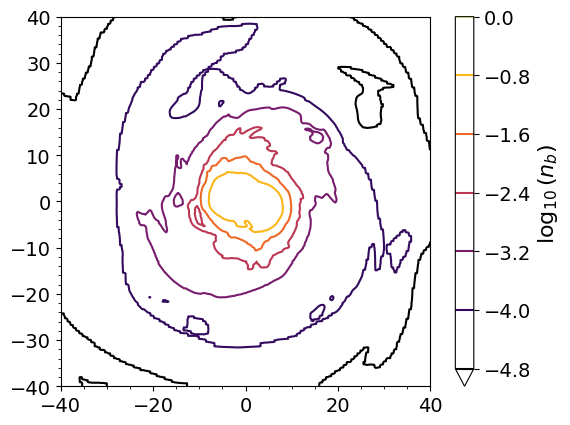

In [80]:
plot_contour(EOS_V_1p3_mrg_data_rho,
            shape=[250,250],
            x0=[-40,-40],
            x1=[40,40],
            vmin=-5,
            vmax=0,
            logscale=True,
            colorbar=True,
            label=r"$\log_{10}(n_b)$")